In [14]:
from sklearn import preprocessing
import pandas as pd
import numpy as np

df = pd.read_csv('datos_abiertos_covid19.csv',nrows = 1000)
df = df[['TABAQUISMO','OBESIDAD','ENTIDAD_UM','CARDIOVASCULAR']].dropna()

In [15]:
# Hacer que todos los valores sean entre 0 y 1

x_scaled = preprocessing.scale(df)
x_scaled

array([[-0.25612954,  0.00949051,  1.13512718, -0.05005772],
       [-0.02370709,  0.00949051,  1.37004588, -0.05005772],
       [-0.02370709, -0.22198528, -0.03946634, -0.05005772],
       ...,
       [-0.02370709, -0.22198528, -0.03946634, -0.05005772],
       [-0.02370709, -0.22198528, -0.03946634, -0.05005772],
       [-0.02370709,  0.00949051,  0.90020847, -0.05005772]])

In [17]:
x_scaled.std(axis = 0)

array([1., 1., 1., 1.])

In [18]:
df.iloc[2]

TABAQUISMO         2
OBESIDAD           1
ENTIDAD_UM        15
CARDIOVASCULAR     2
Name: 2, dtype: int64

In [20]:
x_scaled[2]

array([-0.02370709, -0.22198528, -0.03946634, -0.05005772])

In [21]:
min_max_scaler = preprocessing.MinMaxScaler([0,10])
x_train_minmax =  min_max_scaler.fit_transform(df)
x_train_minmax

array([[0.        , 0.10309278, 8.        , 0.10309278],
       [0.10309278, 0.10309278, 8.66666667, 0.10309278],
       [0.10309278, 0.        , 4.66666667, 0.10309278],
       ...,
       [0.10309278, 0.        , 4.66666667, 0.10309278],
       [0.10309278, 0.        , 4.66666667, 0.10309278],
       [0.10309278, 0.10309278, 7.33333333, 0.10309278]])

In [26]:
df = pd.read_csv('datos_abiertos_covid19.csv',nrows = 1000)
df.head()


,FECHA_ACTUALIZACION,ID_REGISTRO,ORIGEN,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_NAC,ENTIDAD_RES,MUNICIPIO_RES,TIPO_PACIENTE,...,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,RESULTADO,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,2020-07-30,004228,2,3,25,2,25,25,6,1,...,2,2,2,1,1,1,99,México,99,97
1,2020-07-30,1e6804,2,4,27,1,27,27,4,1,...,2,2,2,2,99,1,99,México,99,97
2,2020-07-30,105b61,2,4,15,2,15,15,9,1,...,2,1,2,2,99,1,99,México,99,97
3,2020-07-30,093267,2,4,2,2,2,2,4,2,...,2,1,2,2,99,1,99,México,99,2
4,2020-07-30,008cc5,2,3,25,2,25,25,18,2,...,2,2,2,2,2,1,99,México,99,2


In [28]:
# Para tener una columna por cada categoría de la columna seleccionada

pd.get_dummies(['PAIS_NACIONALIDAD'])

,PAIS_NACIONALIDAD
0,1


In [30]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('datos_abiertos_covid19.csv',nrows = 1000)
newdf = df[['MUNICIPIO_RES','OBESIDAD']].dropna()

In [42]:
newdf = df[['MUNICIPIO_RES','OBESIDAD','TABAQUISMO','ENTIDAD_NAC','SEXO']].dropna()

In [47]:
kmeans =KMeans(n_clusters = 3, random_state = 0, n_jobs = -1).fit(newdf)
kmeans.labels_

/home/enrique/anaconda3/lib/python3.7/site-packages/sklearn/cluster/_kmeans.py:974: FutureWarning: 'n_jobs' was deprecated in version 0.23 and will be removed in 0.25.
  " removed in 0.25.", FutureWarning)


array([0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 2, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 1, 1, 0, 0, 1, 0, 2, 1, 0,
       0, 0, 0, 1, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,

In [48]:
np.unique(kmeans.labels_,return_counts=True)

(array([0, 1, 2], dtype=int32), array([731, 232,  37]))

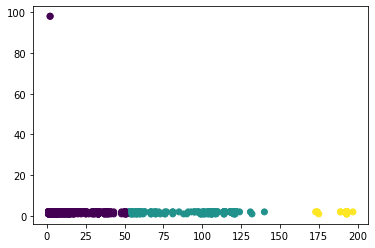

In [49]:
import matplotlib.pyplot as plt
plt.scatter(newdf['MUNICIPIO_RES'],newdf['OBESIDAD'],c = kmeans.labels_)
plt.show()

In [36]:
kmeans.cluster_centers_

array([[  7.3474026 ,   2.07142857],
       [108.41333333,   1.81333333],
       [ 46.62944162,   1.73604061],
       [190.83783784,   1.86486486]])

In [40]:
alldf = pd.read_csv('datos_abiertos_covid19.csv',nrows = 5000)[['MUNICIPIO_RES','OBESIDAD']].dropna()

In [41]:
kmeans.predict(alldf)[0:50]

array([0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 3, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0,
       2, 1, 1, 2, 2, 2, 0, 2, 0, 0, 3, 1, 0, 0, 0, 0, 1, 0, 2, 0, 1, 0,
       0, 0, 0, 2, 0, 0], dtype=int32)